In [ ]:
file_path = "/content/names.txt"

In [ ]:
words = open(file_path, "r").read().splitlines()

In [ ]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [ ]:
len(words)

32033

In [ ]:
min(len(name) for name in words)

2

In [ ]:
max(len(name) for name in words)

15

In [ ]:
import torch

In [ ]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [ ]:
xy, yx = [], []

for w in words[:1]:
    chs = ['.'] + list(w) + ["."]
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xy.append(ix1)
        yx.append(ix2)

xs = torch.tensor(xy)
ys = torch.tensor(yx)
xs

tensor([ 0,  5, 13, 13,  1])

In [ ]:
import torch.nn.functional as F

In [ ]:
# it makes everything zero expect index of interger
xenc = F.one_hot(xs, num_classes=27).float()

In [ ]:
xenc.dtype

torch.float32

In [ ]:
W = torch.randn((27, 27))
W

tensor([[-3.8884e-01, -1.2915e+00, -2.0037e+00, -2.1186e-01,  9.5251e-01,
         -1.6233e+00,  8.2412e-01,  4.6626e-01, -4.6293e-01, -2.6219e-01,
          9.8354e-01,  3.4018e-01,  7.2283e-01,  1.9253e+00, -4.3396e-01,
          1.0558e+00,  2.3075e+00, -8.0938e-01,  6.8157e-01,  3.4200e-01,
          1.1921e-01,  2.8173e-02, -2.1061e-01,  1.3755e+00,  3.0477e-02,
         -1.2235e+00, -8.4450e-01],
        [-6.1595e-01, -6.5508e-01, -2.6244e-02,  1.3239e+00,  5.3271e-01,
          7.6504e-03,  1.5324e-02, -1.8573e+00, -1.6053e+00,  8.7833e-01,
          3.6548e-01,  8.7322e-02,  2.4845e-01,  2.4597e+00,  3.7999e-01,
         -4.0760e-01, -2.5379e-01, -3.3393e-01,  2.1261e-01,  4.7128e-01,
          1.0184e+00,  2.5011e-01, -1.1632e+00, -3.1621e-01, -3.9573e-01,
         -8.9276e-01,  1.1891e+00],
        [ 4.6756e-01, -7.0973e-01, -7.8909e-01, -9.0480e-01, -5.2484e-03,
         -2.4645e-01,  3.2963e-01, -1.3943e-01,  5.5782e-02, -1.4624e-02,
          4.3469e-01, -2.9074e-01, -2.44

In [ ]:
xenc @ W

tensor([[-0.3888, -1.2915, -2.0037, -0.2119,  0.9525, -1.6233,  0.8241,  0.4663,
         -0.4629, -0.2622,  0.9835,  0.3402,  0.7228,  1.9253, -0.4340,  1.0558,
          2.3075, -0.8094,  0.6816,  0.3420,  0.1192,  0.0282, -0.2106,  1.3755,
          0.0305, -1.2235, -0.8445],
        [ 1.3623,  0.9127, -0.3100,  0.4809,  0.0675, -0.2812,  0.1380, -0.4615,
         -0.4424,  1.4241, -0.2714,  1.8392, -0.2178,  1.2979, -0.5108,  0.1753,
          0.1786, -1.3736,  0.8621,  0.3490,  1.0011,  0.4033, -0.6360,  0.2213,
         -0.1679,  0.9132, -0.2939],
        [-0.3165,  0.6637, -2.5327, -0.0776,  0.1511,  1.1730, -0.7970,  1.1172,
         -0.5315,  1.2352, -1.3681,  0.3332,  1.2467, -2.1877, -0.4600,  0.8194,
         -2.7574,  0.3328, -0.5005,  0.8787,  0.4085, -0.5052, -1.3016,  1.0266,
          0.1523,  1.3180,  0.1128],
        [-0.3165,  0.6637, -2.5327, -0.0776,  0.1511,  1.1730, -0.7970,  1.1172,
         -0.5315,  1.2352, -1.3681,  0.3332,  1.2467, -2.1877, -0.4600,  0.8194

In [ ]:
# Reason we use .exp() is that all probabilities must sum up to 1.
# If prob of a is 30% prob of b must go down right?
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdims=True)
probs

tensor([[0.0138, 0.0056, 0.0027, 0.0165, 0.0529, 0.0040, 0.0465, 0.0325, 0.0128,
         0.0157, 0.0545, 0.0287, 0.0420, 0.1399, 0.0132, 0.0586, 0.2049, 0.0091,
         0.0403, 0.0287, 0.0230, 0.0210, 0.0165, 0.0807, 0.0210, 0.0060, 0.0088],
        [0.0853, 0.0544, 0.0160, 0.0353, 0.0234, 0.0165, 0.0251, 0.0138, 0.0140,
         0.0908, 0.0167, 0.1375, 0.0176, 0.0800, 0.0131, 0.0260, 0.0261, 0.0055,
         0.0517, 0.0310, 0.0595, 0.0327, 0.0116, 0.0273, 0.0185, 0.0545, 0.0163],
        [0.0185, 0.0493, 0.0020, 0.0235, 0.0295, 0.0820, 0.0114, 0.0776, 0.0149,
         0.0873, 0.0065, 0.0354, 0.0883, 0.0028, 0.0160, 0.0576, 0.0016, 0.0354,
         0.0154, 0.0611, 0.0382, 0.0153, 0.0069, 0.0708, 0.0296, 0.0948, 0.0284],
        [0.0185, 0.0493, 0.0020, 0.0235, 0.0295, 0.0820, 0.0114, 0.0776, 0.0149,
         0.0873, 0.0065, 0.0354, 0.0883, 0.0028, 0.0160, 0.0576, 0.0016, 0.0354,
         0.0154, 0.0611, 0.0382, 0.0153, 0.0069, 0.0708, 0.0296, 0.0948, 0.0284],
        [0.0124, 0.0119,

In [ ]:
probs[4] # see sum of any row is 1.0

tensor([0.0124, 0.0119, 0.0223, 0.0860, 0.0390, 0.0230, 0.0232, 0.0036, 0.0046,
        0.0551, 0.0330, 0.0250, 0.0293, 0.2677, 0.0334, 0.0152, 0.0177, 0.0164,
        0.0283, 0.0366, 0.0633, 0.0294, 0.0071, 0.0167, 0.0154, 0.0094, 0.0751])

In [ ]:
# ------ <> ------
xs, ys = [], []
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

# initialize the 'network'
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

number of examples:  228146


In [ ]:
# gradient descent
for k in range(1):

  # forward pass
  xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
  logits = xenc @ W # predict log-counts
  counts = logits.exp() # counts, equivalent to N
  probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
  loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()
  print(loss.item())

  # backward pass
  W.grad = None # set to zero the gradient
  loss.backward()

  # update
  W.data += -50 * W.grad

3.7686190605163574


In [ ]:
# finally, sample from the 'neural net' model
g = torch.Generator().manual_seed(2147483647)

for i in range(5):

  out = []
  ix = 0
  while True:

    # ----------
    # BEFORE:
    #p = P[ix]
    # ----------
    # NOW:
    xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    p = counts / counts.sum(1, keepdims=True) # probabilities for next character
    # ----------

    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

texzmkloglquszipczktxhkmpmzistttwinmlgdukzka.
zr.
rocxtpucjwtsc.
gmtokmxczisqytxugkwpt.
dajkkluydjmscdgu.


In [ ]:
# Music chord generator
import pandas as pd

In [ ]:
raw_file = pd.read_csv("/content/chords_mapping.csv")
raw_file.head()

,Unnamed: 0,Chords,Notes,Degrees
0,0,C7,"['do', 'mi', 'sol', 'las']","[1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0]"
1,1,Cmaj7,"['do', 'mi', 'sol', 'si']","[1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1]"
2,2,C9,"['do', 'mi', 'sol', 'las', 're']","[1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0]"
3,3,Cmaj9,"['do', 'mi', 'sol', 'si', 're']","[1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1]"
4,4,Cmajs9,"['do', 'mi', 'sol', 'si', 'res']","[1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1]"


In [ ]:
df = raw_file[["Notes"]]
df.head()

,Notes
0,"['do', 'mi', 'sol', 'las']"
1,"['do', 'mi', 'sol', 'si']"
2,"['do', 'mi', 'sol', 'las', 're']"
3,"['do', 'mi', 'sol', 'si', 're']"
4,"['do', 'mi', 'sol', 'si', 'res']"


In [ ]:
df.shape

(2793, 1)

In [ ]:
max(len(chords.split()) for chords in df["Notes"])

7

In [ ]:
min(len(chords.split()) for chords in df["Notes"])

2

In [ ]:
# How can i know number of distinct notes in my df?
import ast

chords = raw_file["Notes"].apply(ast.literal_eval).tolist()


In [ ]:
unique_notes = set(note for chord in chords for note in chord)
unique_notes

{'do',
 'dos',
 'fa',
 'fas',
 'la',
 'lab',
 'las',
 'mi',
 'mib',
 'mis',
 're',
 'reb',
 'res',
 'si',
 'sib',
 'sol',
 'solb',
 'sols'}

In [ ]:
len(unique_notes)

18

In [ ]:
notes = sorted(unique_notes)
stoi = {s:i+1 for i,s in enumerate(notes)}
stoi['.'] = 0
stoi

{'do': 1,
 'dos': 2,
 'fa': 3,
 'fas': 4,
 'la': 5,
 'lab': 6,
 'las': 7,
 'mi': 8,
 'mib': 9,
 'mis': 10,
 're': 11,
 'reb': 12,
 'res': 13,
 'si': 14,
 'sib': 15,
 'sol': 16,
 'solb': 17,
 'sols': 18,
 '.': 0}

In [ ]:
itos = {i:s for s,i in stoi.items()}
itos

{1: 'do',
 2: 'dos',
 3: 'fa',
 4: 'fas',
 5: 'la',
 6: 'lab',
 7: 'las',
 8: 'mi',
 9: 'mib',
 10: 'mis',
 11: 're',
 12: 'reb',
 13: 'res',
 14: 'si',
 15: 'sib',
 16: 'sol',
 17: 'solb',
 18: 'sols',
 0: '.'}

In [ ]:
b = {}
for chord in chords:
    sub = ["."] + chord + ["."]
    for ch1, ch2 in zip(sub, sub[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

In [ ]:
N = torch.zeros((19, 19), dtype=torch.int32)

In [ ]:
for chord in chords:
    sub = ["."] + chord + ["."]
    for ch1, ch2 in zip(sub, sub[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

In [ ]:
N

tensor([[  0, 156, 156, 156, 156, 156, 153, 156, 156, 153, 156, 156, 153, 156,
         156, 153, 156, 153, 156],
        [234,   0,   5,  31,   5,   1,   1,   2, 434, 145,  40,  54,   0, 346,
           2,   2,   5,   4,   1],
        [156,   1,   0,   0,  40,   1,   0,   1, 346,   0, 308,   5,   0,  44,
           2,   0,   5,   0,   3],
        [ 65,   3,   0,   0,   0, 186, 201,   0,   0,   2,   0,   0,   0,   0,
           0,  30,  19,   0,   0],
        [156,   5,   3,   0,   0, 346,   0, 308,   2,   0,   1,   1,   0,   1,
          40,   0,   5,   0,  44],
        [229, 491, 308,   1,   1,   0,   1,   5,   3,   5,   1,  50, 135,   5,
          60,   5,   2,   1,   1],
        [ 55, 194,   0,   0,   0,   0,   0,   0,   0,   3,   0,   0,  26,   0,
         243,  28,   0,   2,   0],
        [156,  44, 346,   0,   1,   1,   0,   0,   5,   0,   3, 308,   0,  40,
           5,   0,   1,   0,   2],
        [237,   2,   1,   5,  44,  50, 120,   5,   0,   1,   5,   2,   1,   1,
         

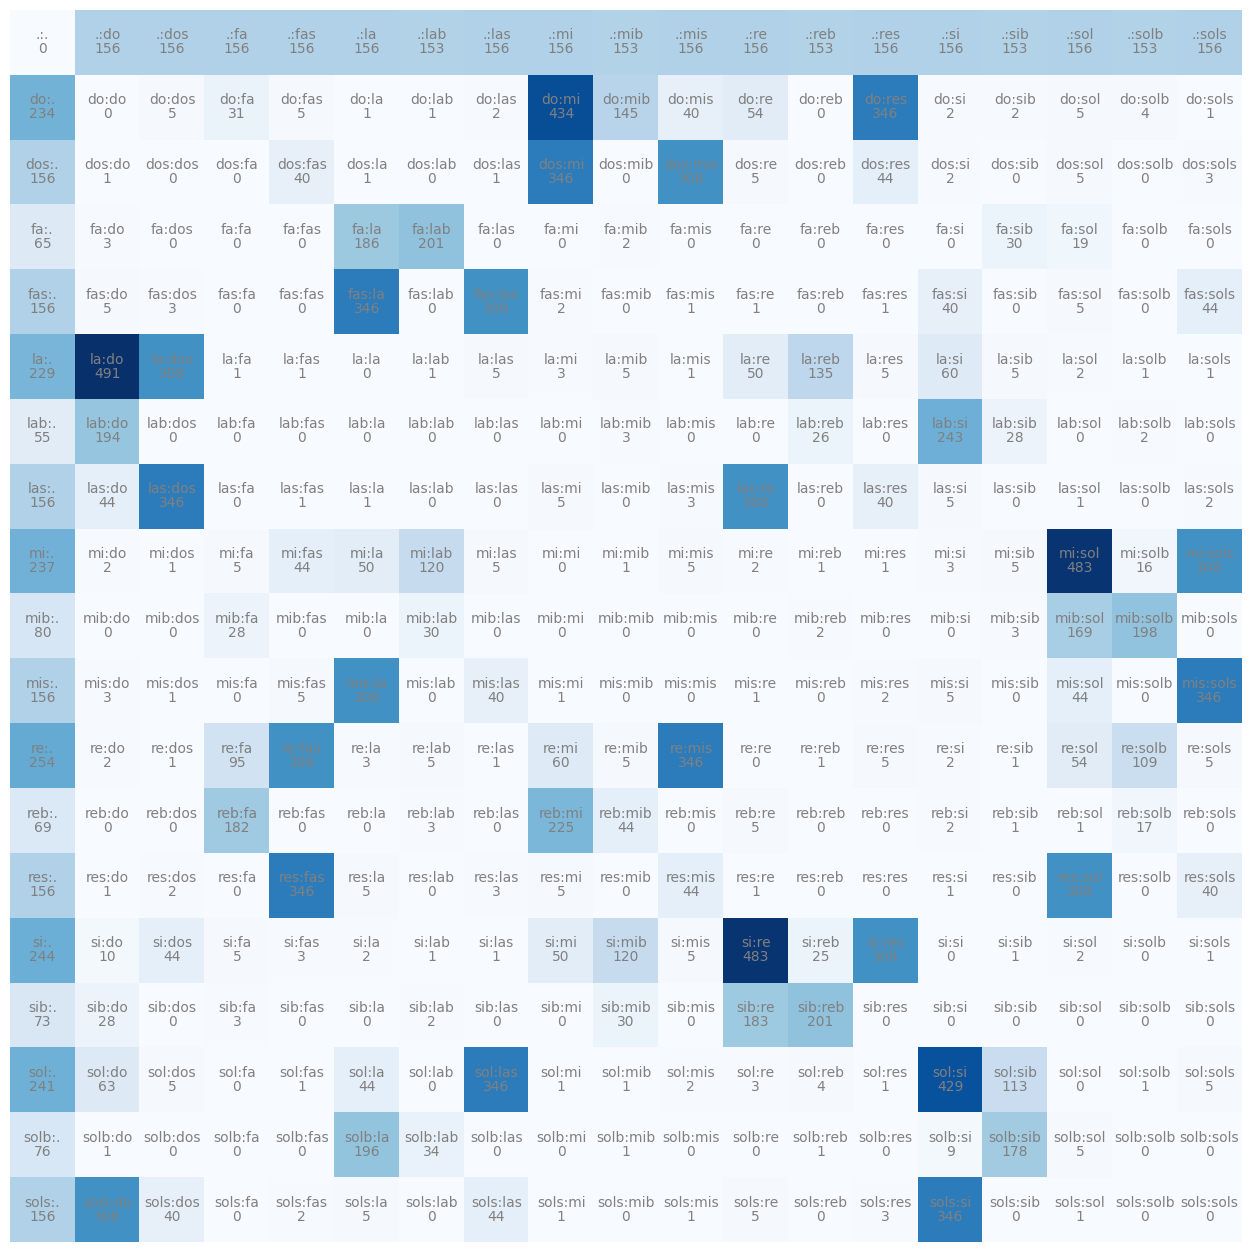

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(19):
    for j in range(19):
        chstr = itos[i] + ":" + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [ ]:
xs = []
ys = []
for chord in chords:
    sub = ["."] + chord + ["."]
    for ch1, ch2 in zip(sub, sub[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [ ]:
xs

tensor([ 0,  1,  8,  ..., 12,  8, 16])

In [ ]:
ys

tensor([ 1,  8, 16,  ...,  8, 16,  0])

In [ ]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=19).float()
xenc

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 1., 0., 0.]])

In [ ]:
xenc.shape

torch.Size([19129, 19])

In [ ]:
W = torch.randn((19, 19), requires_grad=True)

In [ ]:
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdims=True)
probs

tensor([[0.2468, 0.0451, 0.0144,  ..., 0.0612, 0.0247, 0.0362],
        [0.0551, 0.0140, 0.0402,  ..., 0.0695, 0.0370, 0.0229],
        [0.0434, 0.0079, 0.0843,  ..., 0.0159, 0.0288, 0.0059],
        ...,
        [0.0505, 0.0344, 0.0990,  ..., 0.0317, 0.0262, 0.0103],
        [0.0434, 0.0079, 0.0843,  ..., 0.0159, 0.0288, 0.0059],
        [0.1091, 0.0391, 0.0164,  ..., 0.0276, 0.0164, 0.0238]],
       grad_fn=<DivBackward0>)

In [ ]:
loss = -probs[torch.arange(len(ys)), ys].log().mean()

In [ ]:
loss.item()

3.5605885982513428

In [ ]:
for k in range(100):
    xenc = F.one_hot(xs, num_classes=19).float()
    logits = xenc @ W
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdim=True)
    loss = -probs[torch.arange(len(ys)), ys].log().mean()

    W.grad = None
    loss.backward()

    W.data += -50.0 * W.grad

In [ ]:
import torch

g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out = []
    ix = 0

    while True:
        xenc = torch.nn.functional.one_hot(
            torch.tensor([ix]), num_classes=19
        ).float()
        logits = xenc @ W
        counts = logits.exp()
        probs = counts / counts.sum(1, keepdim=True)
        ix = torch.multinomial(
            probs, num_samples=1, replacement=True, generator=g
        ).item()

        out.append(itos[ix])
        if ix == 0:
            break

    print(" ".join(out))

fa la dos mi dos mis las dos mi .
si re fas la do mi lab .
do res sol si .
reb fa .
fa lab do res la do .
